In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt

In [101]:
train_labels_fpath = "mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte"
train_images_fpath = "mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte"
test_labels_fpath = "mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte"
test_images_fpath = "mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte"
np.random.seed(2023115)

In [102]:

def sample_data(images, labels, sample_size=100):
    cats=[]
    for l in labels:
        if (l not in cats):
            cats.append(l)
    final_imgs=[]
    final_tags=[]
    for c in cats:
        idxs=[]
        for i in range(len(labels)):
            if(labels[i]==c):
                idxs.append(i)
        chosen_idx = np.random.choice(idxs, sample_size, replace=False)
        for idx in chosen_idx:
            final_imgs.append(images[idx])
            final_tags.append(labels[idx])
    X = np.array(final_imgs)
    y = np.array(final_tags)
    p = np.random.permutation(len(y))
    X = X[p]
    y = y[p]
    
    return X, y

In [103]:
def load_dataset(image_file, label_file):
    with open(label_file, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    with open(image_file, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images, labels
    

In [104]:
def filter012(images, labels):
    classes=(0, 1, 2)
    indices = np.where((labels == classes[0]) | (labels == classes[1]) | (labels == classes[2]))[0]
    return images[indices], labels[indices]

In [105]:
def preprocess(images):
    max_pixel_value = 255.0
    samples_cnt = images.shape[0]
    flatten_images = images.reshape(samples_cnt, -1)
    norm_images = flatten_images / max_pixel_value
    return norm_images

In [106]:
def principalComponent(train_images, var, comp=None):
    print("Size of Data Matrix", train_images.shape)
    data_mu = np.mean(train_images, axis=1,keepdims=True)
    corrected_data_matrix = train_images - data_mu
    cov_S = np.dot(corrected_data_matrix, corrected_data_matrix.T)
    cov_S = (1/299)* cov_S

    eigVals, vec = np.linalg.eig(cov_S)
    eigVals = np.real(eigVals)
    vec = np.real(vec)

    sorted_idx = np.argsort(eigVals)
    sorted_idx = sorted_idx[::-1]
    eigVals = eigVals[sorted_idx]
    vec = vec[:, sorted_idx]

    if(comp is not None):
        k = comp
    elif(var is not None):
        total_var = np.sum(eigVals)
        var_sum = 0
        k = 0
        for i in range(len(eigVals)):
            var_sum += eigVals[i]
            if (var_sum / total_var) >= var:
                k = i + 1  # We need i+1 components because index i is the (i+1)th component
                break
    else:
        k = train_images.shape[0]
    Up = vec[:, :k]
    Y = np.dot(Up.T, corrected_data_matrix)
    return Y, Up, eigVals[:k]
    
    

In [107]:
def fischerDA(train_images, train_labels):
    feat_cnt = train_images.shape[0]
    cats = [0,1,2]
    mu_glob = np.mean(train_images, axis=1, keepdims=True)
    S_w = np.zeros((feat_cnt, feat_cnt))
    S_bw = np.zeros((feat_cnt, feat_cnt))
    for idx in cats:
        samples=train_images[:, train_labels == idx]
        mu_c= np.mean(samples, axis=1, keepdims=True)
        centered =  samples - mu_c
        S_w+=(centered @ centered.T)
        mu_diff=mu_c-mu_glob
        n_c=samples.shape[1]
        S_bw+=n_c * (mu_diff @ mu_diff.T)

    S_w += np.eye(feat_cnt) * 1e-6 #(sig+ l*I) to ensure invertibility
    mat = np.linalg.inv(S_w) @ S_bw
    eigVals, vec = np.linalg.eig(mat)
    idx_desc = np.argsort(eigVals)[::-1]
    top_idx = idx_desc[:len(cats) - 1]
    W = vec[:, top_idx]
    return np.real(W)

In [ ]:
def accuracy(pred, labels):
    num_sample = len(pred)
    correct = np.sum(pred == labels)
    return (correct / num_sample)*100

def project_pca(data, Up, mean):
    return Up.T @ (data.T - mean)

def project_test_pca(X_test_t, Up, train_mean):
    centered_test = X_test_t - train_mean
    return np.dot(Up.T, centered_test)

In [109]:
def MLEstimate(train_images, train_labels):
    reg = 1e-5
    classes = np.unique(train_labels)
    params={}
    for c in classes:
        class_images = train_images[train_labels == c]
        N = class_images.shape[0]
        mean = np.mean(class_images, axis=0) 
        print(mean.shape)      ## u
        centered_images = class_images - mean ## (x-u)
        covmat = np.dot(centered_images.T, centered_images) / N  ## 1/N (x-u)^t (x-u)
        covmat += reg * np.eye(covmat.shape[0]) ## Regularization
        prior = N / len(train_labels) ## P(y=c) = N_c/N
        params[c] = (mean, covmat, prior)
    return params

In [110]:
def LDA(test_images, test_labels, params):
    labels = list(params.keys())
    cov = np.zeros_like(params[labels[0]][1])
    for c in labels:
        cov += params[c][1]
    N = len(labels)
    cov = cov / len(labels)
    cov_inv = np.linalg.pinv(cov)
    pred_labels = []
    for x in test_images:
        scores = []
        for c in labels:
            mean = params[c][0]
            prior = params[c][2]
            score = -0.5 * np.dot(np.dot((x - mean).T, cov_inv), (x - mean)) + np.log(prior)
            scores.append(score)
        pred_labels.append(labels[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    accuracy = np.mean(pred_labels == test_labels)
    print("LDA Discriminant values for first test sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(labels, scores)])
    print(f"LDA Accuracy: {accuracy:.4f}")
    

In [111]:
def QDA(test_images, test_labels, params):
    labels = list(params.keys())
    pred_labels = []
    cat_params = {}
    for idx in labels:
        covmat = params[idx][1]
        try:
            cov_inv = np.linalg.inv(covmat)
            sign, logdet = np.linalg.slogdet(covmat)
            if (sign <= 0):
                print(f"Warning: Covariance matrix for class {c} is not positive definite.")
        except np.linalg.LinAlgError: # Singular matrix, use pseudo-inverse
            cov_inv = np.linalg.pinv(covmat)
            logdet = 0
        cat_params[idx] = (cov_inv, logdet)
    for x in test_images:
        scores = []
        for c in labels:
            mu = params[c][0]
            prior = params[c][2]
            cov_inv, logdet = cat_params[c]
            score = -0.5 * np.dot(np.dot((x - mu).T, cov_inv), (x - mu)) - 0.5 * logdet + np.log(prior)
            scores.append(score)
        pred_labels.append(labels[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    accuracy = np.mean(pred_labels == test_labels)
    print("QDA Discriminant values for first test sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(labels, scores)])
    print(f"QDA Accuracy: {accuracy:.4f}")

In [112]:

train_imgs_raw, train_labels_raw = load_dataset(train_images_fpath, train_labels_fpath)
test_imgs_raw, test_labels_raw = load_dataset(test_images_fpath, test_labels_fpath)
train_imgs_012, train_labels_012 = filter012(train_imgs_raw, train_labels_raw)
test_imgs_012, test_labels_012 = filter012(test_imgs_raw, test_labels_raw)

# Randomly sample 100 from each class
X_train, y_train = sample_data(train_imgs_012, train_labels_012)
X_test, y_test = sample_data(test_imgs_012, test_labels_012)
X_train_norm = preprocess(X_train)
X_test_norm = preprocess(X_test)
X_train_t = X_train_norm.T 
X_test_t = X_test_norm.T

print("Train shape (features, samples):", X_train_t.shape)
print("Test shape (features, samples):", X_test_t.shape)

Train shape (features, samples): (784, 300)
Test shape (features, samples): (784, 300)


Size of Data Matrix (784, 300)
Components used for 75% variance: 20


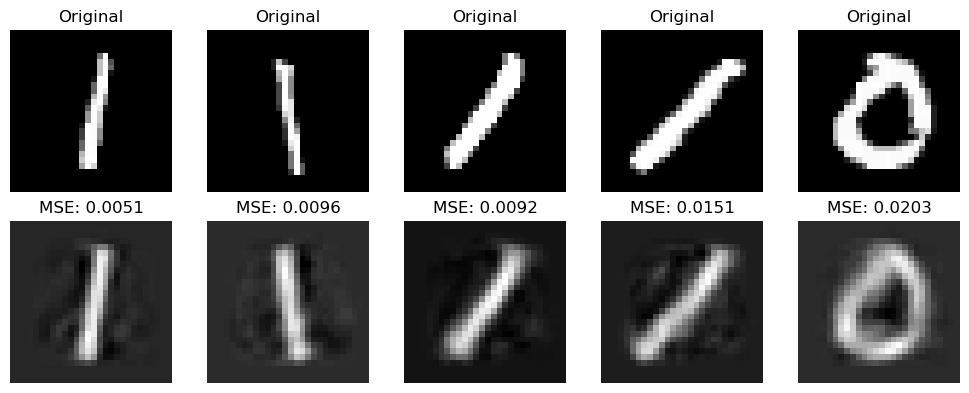

In [113]:
# 1. Project and Reconstruct
Y_t_75, Up_75, _ = principalComponent(X_train_t, var=0.75)
mean_train = np.mean(X_train_t, axis=1, keepdims=True)
X_recon = (Up_75 @ Y_t_75) + mean_train

print(f"Components used for 75% variance: {Y_t_75.shape[0]}")
plt.figure(figsize=(10, 4))
for i in range(5):
    mse = np.mean((X_train_t[:, i] - X_recon[:, i])**2)
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_t[:, i].reshape(28,28), cmap='gray'), plt.axis('off')
    plt.title("Original")
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_recon[:, i].reshape(28,28), cmap='gray'), plt.axis('off')
    plt.title(f"MSE: {mse:.4f}")
plt.tight_layout()
plt.show()

In [114]:

fda_vec = fischerDA(X_train_t, y_train)
X_train_fda = np.dot(X_train_norm, fda_vec) 
X_test_fda = np.dot(X_test_norm, fda_vec)
params_fda = MLEstimate(X_train_fda, y_train)

print("FDA with LDA\n")
print("Train Accuracy:")
LDA(X_train_fda, y_train, params_fda)
print("Test Accuracy:")
LDA(X_test_fda, y_test, params_fda)

print()

print("FDA with QDA\n")
print("Train Accuracy:")
QDA(X_train_fda, y_train, params_fda)
print("Test Accuracy:")
QDA(X_test_fda, y_test, params_fda)

(2,)
(2,)
(2,)
FDA with LDA

Train Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -1.10', 'Class 1: -14767.49', 'Class 2: -10301.65']
LDA Accuracy: 1.0000
Test Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -9492.84', 'Class 1: -2118.92', 'Class 2: -1551.79']
LDA Accuracy: 0.8667

FDA with QDA

Train Accuracy:
QDA Discriminant values for first test sample: ['Class 0: 10.41', 'Class 1: -14755.97', 'Class 2: -10290.14']
QDA Accuracy: 1.0000
Test Accuracy:
QDA Discriminant values for first test sample: ['Class 0: -9481.32', 'Class 1: -2107.41', 'Class 2: -1540.28']
QDA Accuracy: 0.8667


In [ ]:
print(" PCA 75% Variance + LDA")
Y_test_75 = project_test_pca(X_test_t, Up_75, mean_train)

p_var75 = MLEstimate(Y_t_75.T, y_train)
print("Train Accuracy:"); LDA(Y_t_75.T, y_train, p_var75)
print("Test Accuracy:"); LDA(Y_test_75.T, y_test, p_var75)

print("\n")
print("PCA 90% Variance + LDA")
Y_train_90, Up_90, _ = principalComponent(X_train_t, var=0.90, comp=None)
Y_test_90 = project_test_pca(X_test_t, Up_90, mean_train)
p_var90 = MLEstimate(Y_train_90.T, y_train)
print("Train Accuracy:"); LDA(Y_train_90.T, y_train, p_var90)
print("Test Accuracy:"); LDA(Y_test_90.T, y_test, p_var90)

print("\n")
print("PCA First 2 Components + LDA")
Y_train_2, Up_2, _ = principalComponent(X_train_t, var=None, comp=2)
Y_test_2 = project_test_pca(X_test_t, Up_2, mean_train)
p_var2 = MLEstimate(Y_train_2.T, y_train)
print("Train Accuracy:"); LDA(Y_train_2.T, y_train, p_var2)
print("Test Accuracy:"); LDA(Y_test_2.T, y_test, p_var2)

 PCA 75% Variance + LDA
(20,)
(20,)
(20,)
Train Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -18.10', 'Class 1: -40.02', 'Class 2: -26.25']
LDA Accuracy: 0.9667
Test Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -23.70', 'Class 1: -17.12', 'Class 2: -8.24']
LDA Accuracy: 0.9400


PCA 90% Variance + LDA
Size of Data Matrix (784, 300)
(51,)
(51,)
(51,)
Train Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -49.35', 'Class 1: -88.11', 'Class 2: -65.68']
LDA Accuracy: 0.9767
Test Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -50.33', 'Class 1: -43.15', 'Class 2: -31.10']
LDA Accuracy: 0.9333


PCA First 2 Components + LDA
Size of Data Matrix (784, 300)
(2,)
(2,)
(2,)
Train Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -2.56', 'Class 1: -8.32', 'Class 2: -4.37']
LDA Accuracy: 0.9033
Test Accuracy:
LDA Discriminant values for first test sample: ['Class 0: -13.43', 'Class 1: -4.38', 'Cl

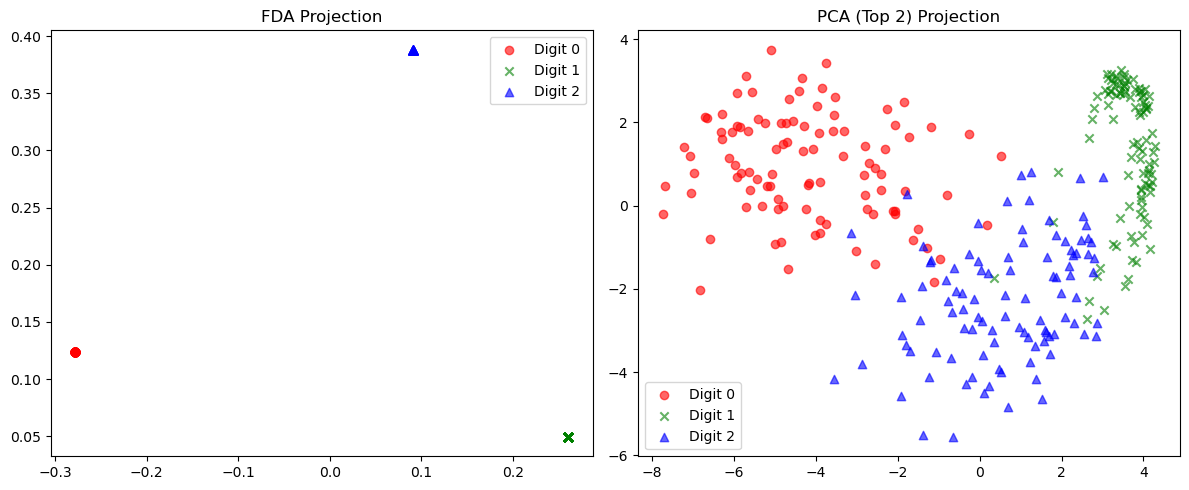

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
targets = [(X_train_fda, "FDA Projection"), (Y_train_2.T, "PCA (Top 2) Projection")]
colors, markers = ['r', 'g', 'b'], ['o', 'x', '^']

for ax, (data, title) in zip(axes, targets):
    for i, c in enumerate([0, 1, 2]):
        mask = (y_train == c)
        ax.scatter(data[mask, 0], data[mask, 1], c=colors[i], marker=markers[i], label=f"Digit {c}", alpha=0.6)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()